In [1]:
!pip install ctgan --quiet
from ctgan import CTGAN


In [2]:
!mkdir -p data
!unzip -o CSV_train.csv.zip -d data
!unzip -o CSV_test.csv.zip -d data
!ls -lh data


Archive:  CSV_train.csv.zip
  inflating: data/CSV_train.csv      
Archive:  CSV_test.csv.zip
  inflating: data/CSV_test.csv       
total 298M
-rw-r--r-- 1 root root  31M Apr 17  2024 CSV_test.csv
-rw-r--r-- 1 root root 268M Apr 17  2024 CSV_train.csv


In [3]:
import pandas as pd, glob

na_vals = ["", "NA", "NaN", -999.25]

train_path = [p for p in glob.glob("data/*.csv") if "train" in p.lower()][0]
test_path  = [p for p in glob.glob("data/*.csv") if "test"  in p.lower()][0]

train = pd.read_csv(train_path, sep=";", na_values=na_vals, low_memory=False)
test  = pd.read_csv(test_path,  sep=";", na_values=na_vals, low_memory=False)
preds = pd.read_csv("predictions.csv")

print("Train shape:", train.shape)
print("Test  shape:", test.shape)
print("Preds shape:", preds.shape)

display(train.head(2))
display(test.head(2))
display(preds.head(2))


Train shape: (1170511, 29)
Test  shape: (136786, 27)
Preds shape: (136786, 1)


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.61141,...,34.63641,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000,1.0
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.61807,...,34.63641,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000,1.0


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
0,15/9-14,480.628001,423244.5,6461862.5,-455.624420,NORDLAND GP.,NaN,19.2031,NaN,1.613886,...,35.525719,NaN,96.461990,NaN,NaN,-0.538873,0.130611,NaN,NaN,NaN
1,15/9-14,480.780001,423244.5,6461862.5,-455.776428,NORDLAND GP.,NaN,19.2031,NaN,1.574376,...,36.158520,NaN,96.454399,NaN,NaN,-0.539232,0.130611,NaN,NaN,NaN


,lithology
0,65000
1,65000


In [4]:
import glob
print(glob.glob("data/*.csv"))


['data/CSV_test.csv', 'data/CSV_train.csv']


In [5]:
# Add predictions to test
test["FORCE_2020_LITHOFACIES_LITHOLOGY"] = preds["lithology"].values

# Confidence column (if you want, can set to NaN or 1.0)
test["FORCE_2020_LITHOFACIES_CONFIDENCE"] = 1.0

print(test.shape)
display(test.head(3))


(136786, 29)


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-14,480.628001,423244.5,6461862.5,-455.624420,NORDLAND GP.,NaN,19.2031,NaN,1.613886,...,96.461990,NaN,NaN,-0.538873,0.130611,NaN,NaN,NaN,65000,1.0
1,15/9-14,480.780001,423244.5,6461862.5,-455.776428,NORDLAND GP.,NaN,19.2031,NaN,1.574376,...,96.454399,NaN,NaN,-0.539232,0.130611,NaN,NaN,NaN,65000,1.0
2,15/9-14,480.932001,423244.5,6461862.5,-455.928436,NORDLAND GP.,NaN,19.2031,NaN,1.436627,...,96.446686,NaN,NaN,-0.540830,0.130611,NaN,NaN,NaN,65000,1.0


In [6]:
train["_is_train"] = 1
test["_is_train"]  = 0

combined = pd.concat([train, test], ignore_index=True, sort=False)
print("Combined shape:", combined.shape)

# quick check
print("Train rows:", (combined["_is_train"]==1).sum())
print("Test rows :", (combined["_is_train"]==0).sum())

combined.to_csv("combined.csv", index=False)
print("Saved -> combined.csv")


Combined shape: (1307297, 30)
Train rows: 1170511
Test rows : 136786
Saved -> combined.csv


In [7]:
ps=pd.read_csv('/content/combined.csv')
ps.head()


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,_is_train
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000,1.0,1
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000,1.0,1
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,NaN,NaN,-0.574245,NaN,NaN,NaN,NaN,65000,1.0,1
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,NaN,NaN,-0.586315,NaN,NaN,NaN,NaN,65000,1.0,1
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,NaN,NaN,-0.597914,NaN,NaN,NaN,NaN,65000,1.0,1


In [8]:
print("First 5 from preds:", preds["lithology"].head().tolist())
print("First 5 in test:", test["FORCE_2020_LITHOFACIES_LITHOLOGY"].head().tolist())


First 5 from preds: [65000, 65000, 65000, 65000, 65000]
First 5 in test: [65000, 65000, 65000, 65000, 65000]


In [10]:
# ------------------ 0. Install Dependencies ------------------
!pip install pandas scikit-learn torch

# ------------------ 1. Imports ------------------
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from collections import defaultdict

# ------------------ 2. Load Data ------------------
df = pd.read_csv("/content/combined.csv")

# ------------------ 3. Preprocessing ------------------
target_col = 'FORCE_2020_LITHOFACIES_LITHOLOGY'
#df = df[~df[target_col].isin([86000, 93000])]  # remove unwanted classes

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != target_col]

# Fill missing values
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Encode categorical features
label_encoders = {}
cat_dims = []
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    cat_dims.append(df[col].nunique())

# Normalize numerical features
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# ------------------ 4. Split 50K for Testing Only ------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

test_df = df.iloc[:120000]         # 50k test set
train_val_df = df.iloc[120000:]    # rest for training + validation



/tmp/ipython-input-2614666153.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-2614666153.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [11]:
train_val_df[target_col].unique()
# Count samples per class
print( train_val_df[target_col].value_counts())
print(test_df[target_col].value_counts())

FORCE_2020_LITHOFACIES_LITHOLOGY
65000    744528
30000    175315
65030    142472
70000     55985
80000     30896
99000     14572
70032      9551
88000      7466
90000      3862
74000      1537
86000      1020
93000        93
Name: count, dtype: int64
FORCE_2020_LITHOFACIES_LITHOLOGY
65000    74877
30000    17685
65030    14688
70000     5689
80000     3164
99000     1509
70032      962
88000      747
90000      404
74000      151
86000      114
93000       10
Name: count, dtype: int64


In [12]:
# ------------------ 4.5 CTGAN Augmentation + Quality Evaluation ------------------
!pip install ctgan --quiet
from ctgan import CTGAN
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ------------------ Prepare features for CTGAN ------------------
features = categorical_cols + numerical_cols

# Dictionary to store synthetic samples per class
synthetic_data_dict = {}

# List to store augmented data parts
augmented_parts = []

# Target minority classes
minority_classes = [74000, 86000, 93000]

for cls in minority_classes:
    print(f"\nTraining CTGAN for class {cls}")

    cls_df = train_val_df[train_val_df[target_col] == cls]

    if len(cls_df) == 0:
        print(f"Skipping empty class {cls}")
        continue

    # Input features for CTGAN
    synth_input = cls_df[features]

    # Determine categorical columns among features
    ctgan_categorical = [col for col in categorical_cols if col in features]

    # Train CTGAN
    #ctgan = CTGAN(epochs=30)
    #ctgan.fit(synth_input, discrete_columns=ctgan_categorical)
    ctgan = CTGAN(epochs=30, cuda=False)  # run in single process
    ctgan.fit(synth_input, discrete_columns=ctgan_categorical)

    # Number of synthetic samples needed
    n_required = 5000 - len(cls_df)
    if n_required <= 0:
        print(f"Class {cls} already has >= 5000 samples")
        synthetic = pd.DataFrame()
    else:
        synthetic = ctgan.sample(n_required)
        synthetic.columns = features
        synthetic[target_col] = cls

        # Store synthetic data for evaluation
        synthetic_data_dict[cls] = synthetic.copy()

    # Combine real + synthetic
    augmented_parts.append(pd.concat([cls_df, synthetic], axis=0))

# Combine all augmented parts
augmented_train_df = pd.concat(augmented_parts).reset_index(drop=True)
print("\nAugmented train data shape:", augmented_train_df.shape)



Training CTGAN for class 74000


/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(



Training CTGAN for class 86000


/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(



Training CTGAN for class 93000


/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(



Augmented train data shape: (15000, 30)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [16]:
combined = pd.concat([real, synth], axis=0)

# Fill NaNs
combined = combined.fillna(combined.median())




KS Test Results for Class 74000:

WELL                            KS=0.051   p=0.0079
GROUP                           KS=0.145   p=0.0000
FORMATION                       KS=0.180   p=0.0000
DEPTH_MD                        KS=0.243   p=0.0000
X_LOC                           KS=0.182   p=0.0000
Y_LOC                           KS=0.195   p=0.0000
Z_LOC                           KS=0.083   p=0.0000
CALI                            KS=0.200   p=0.0000
RSHA                            KS=0.502   p=0.0000
RMED                            KS=0.643   p=0.0000
RDEP                            KS=0.345   p=0.0000
RHOB                            KS=0.373   p=0.0000
GR                              KS=0.404   p=0.0000
SGR                             KS=0.860   p=0.0000
NPHI                            KS=0.474   p=0.0000
PEF                             KS=0.552   p=0.0000
DTC                             KS=0.246   p=0.0000
SP                              KS=0.367   p=0.0000
BS                           

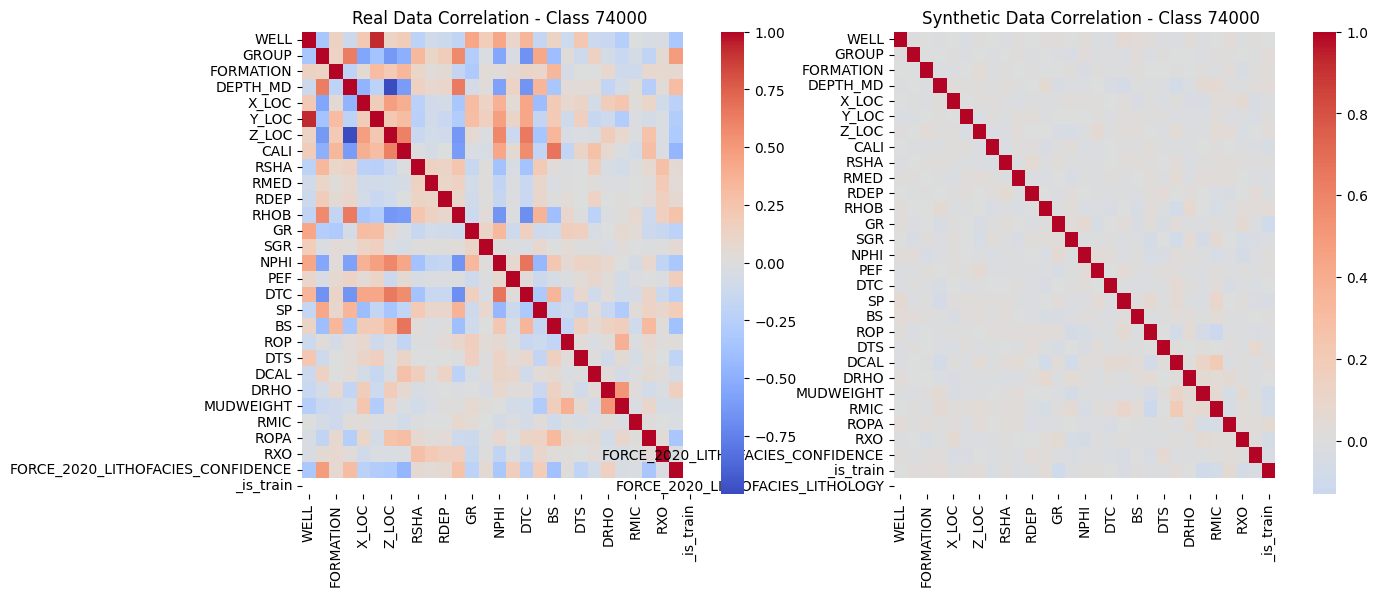

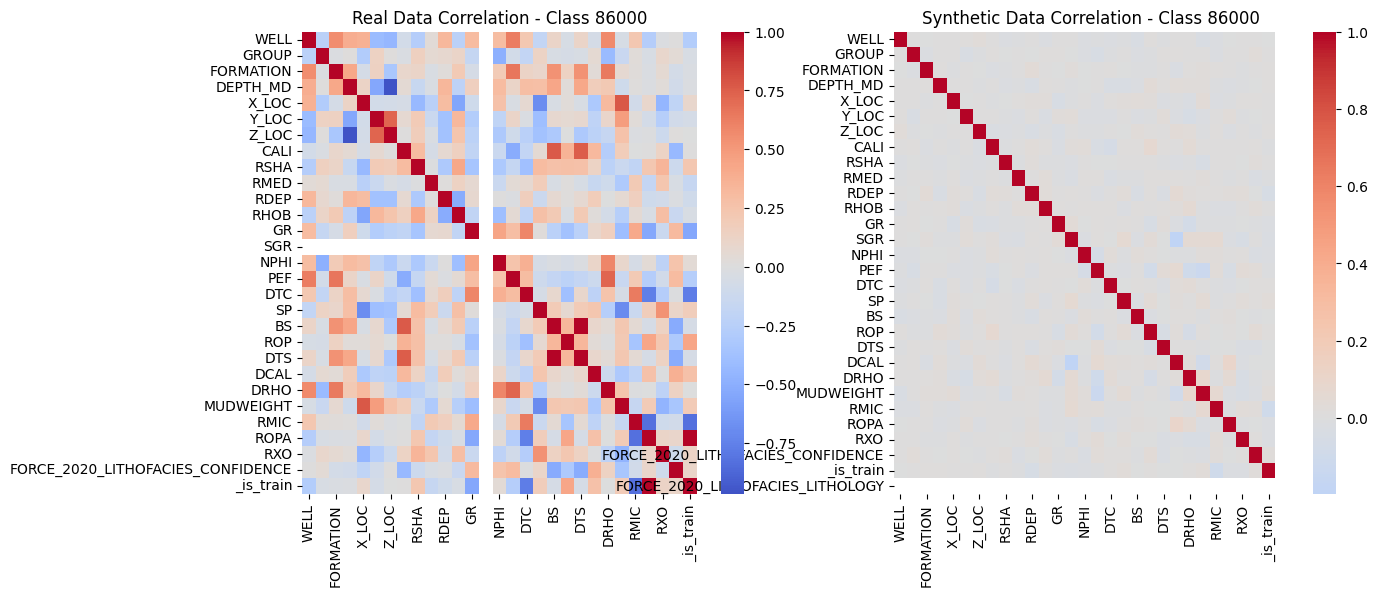

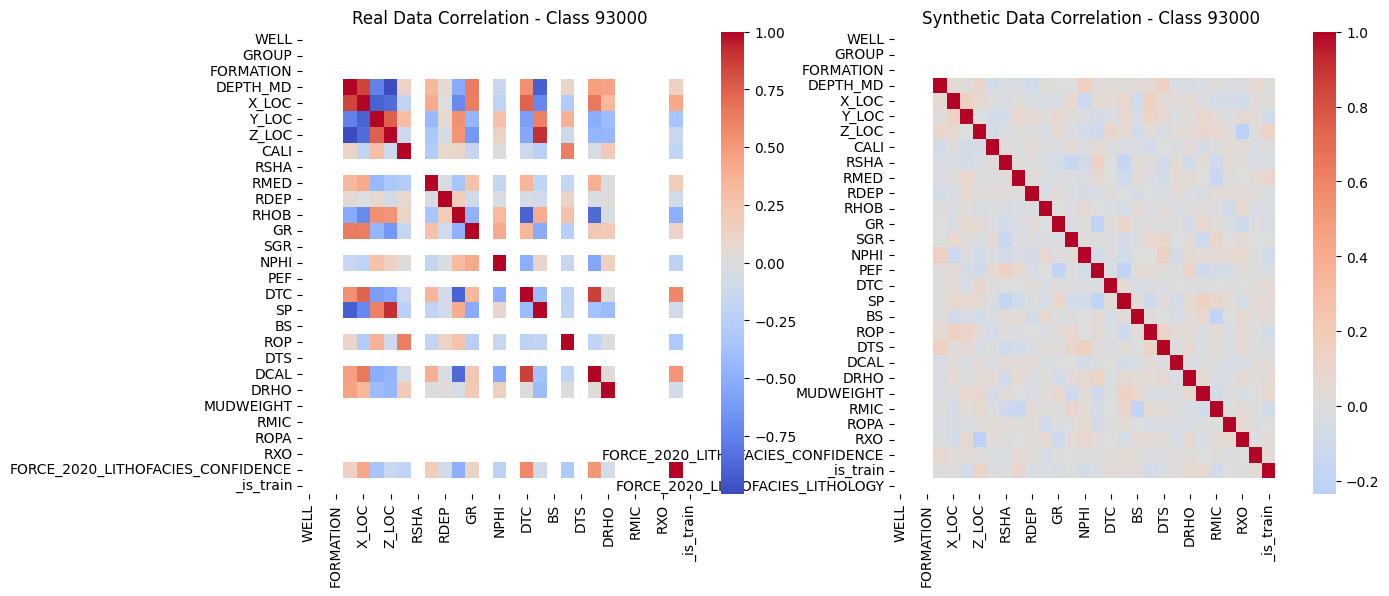

In [19]:


# ------------------ Step 2: KS Test ------------------
for cls in minority_classes:
    real = train_val_df[train_val_df[target_col] == cls][features]
    synth = synthetic_data_dict.get(cls)

    if synth is None or synth.empty:
        print(f"No synthetic data for class {cls}, skipping KS test")
        continue

    print(f"\nKS Test Results for Class {cls}:\n")
    for col in features:
        stat, p = ks_2samp(real[col], synth[col])
        print(f"{col:30}  KS={stat:.3f}   p={p:.4f}")

# ------------------ Optional Step 3: Correlation Heatmaps ------------------
for cls in minority_classes:
    real = train_val_df[train_val_df[target_col] == cls][features]
    synth = synthetic_data_dict.get(cls)

    if synth is None or synth.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    sns.heatmap(real.corr(), ax=axes[0], cmap='coolwarm', center=0)
    axes[0].set_title(f"Real Data Correlation - Class {cls}")
    sns.heatmap(synth.corr(), ax=axes[1], cmap='coolwarm', center=0)
    axes[1].set_title(f"Synthetic Data Correlation - Class {cls}")
    plt.show()


In [13]:
# ------------------ 4.5. CTGAN Oversampling ------------------

# Identify your target column
target_col = 'FORCE_2020_LITHOFACIES_LITHOLOGY'

# Choose the minority classes you want to oversample
minority_classes = [74000, 86000, 93000]  # update if needed
desired_samples_per_class = 5000

augmented_parts = []

for cls in minority_classes:
    cls_df = train_val_df[train_val_df[target_col] == cls]

    # If class already >= 5000, skip
    if len(cls_df) >= desired_samples_per_class:
        augmented_parts.append(cls_df)
        continue

    print(f"Training CTGAN for class {cls}, current size = {len(cls_df)}")

    # Separate to synthesize only features (without target)
    synth_input = cls_df.drop(columns=[target_col])

    # Determine categorical feature names for CTGAN
    ctgan_categorical = [col for col in categorical_cols]  # same as before

    # Train CTGAN
    ctgan = CTGAN(epochs=30)
    ctgan.fit(synth_input, discrete_columns=ctgan_categorical)

    # Number of samples needed
    n_generate = desired_samples_per_class - len(cls_df)

    # Generate
    synthetic_data = ctgan.sample(n_generate)

    # Add back the target class
    synthetic_data[target_col] = cls

    augmented_parts.append(pd.concat([cls_df, synthetic_data], axis=0))

# Combine oversampled classes with majority classes
majority_df = train_val_df[~train_val_df[target_col].isin(minority_classes)]
train_df_balanced = pd.concat([majority_df] + augmented_parts).reset_index(drop=True)

print("Final training set size:", len(train_df_balanced))


Training CTGAN for class 74000, current size = 1537


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Training CTGAN for class 86000, current size = 1020
Training CTGAN for class 93000, current size = 93
Final training set size: 1199647


In [ ]:
synthetic_data_dict = {}   # <---- ADD THIS

for cls in [74000, 86000, 93000]:
    print(f"Training CTGAN for class {cls}")

    cls_df = train_val_df[train_val_df[target_col] == cls]

    if len(cls_df) == 0:
        print("Skipping empty class")
        continue

    synth_input = cls_df[features]

    ctgan = CTGAN(epochs=30)
    ctgan.fit(synth_input, discrete_columns=ctgan_categorical)

    n_required = 5000 - len(cls_df)
    if n_required <= 0:
        print("Already ≥5000 samples")
        synthetic = pd.DataFrame()
    else:
        synthetic = ctgan.sample(n_required)
        synthetic.columns = features

    synthetic[target_col] = cls

    #  SAVE synthetic samples for later visualization / KS test
    synthetic_data_dict[cls] = synthetic.copy()

    augmented_parts.append(pd.concat([cls_df, synthetic], axis=0))


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cls = 74000

real = train_val_df[train_val_df[target_col] == cls].drop(columns=[target_col])
synth = synthetic_data_dict[cls].drop(columns=[target_col])

# Combine for PCA
combined = pd.concat([real, synth], axis=0)
labels = np.array([0]*len(real) + [1]*len(synth))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[labels==0, 0], pca_result[labels==0, 1], alpha=0.5, label="Real")
plt.scatter(pca_result[labels==1, 0], pca_result[labels==1, 1], alpha=0.5, label="Synthetic")
plt.legend()
plt.title(f"PCA Comparison for Class {cls}")
plt.show()


In [ ]:
from scipy.stats import ks_2samp

for col in real.columns:
    stat, p = ks_2samp(real[col], synth[col])
    print(f"{col}: KS={stat:.3f}, p={p:.4f}")


In [ ]:
# ------------------ 5. Split Remaining into Train/Val ------------------
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df[target_col], random_state=42
)

# ------------------ 6. Prepare Data ------------------
def prepare_features(df_slice):
    X_cat = df_slice[categorical_cols].values
    X_num = df_slice[numerical_cols].values
    y = LabelEncoder().fit_transform(df_slice[target_col].values)
    return X_cat, X_num, y

X_train_cat, X_train_num, y_train = prepare_features(train_df)
X_val_cat, X_val_num, y_val = prepare_features(val_df)
X_test_cat, X_test_num, y_test = prepare_features(test_df)

num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

# ------------------ 7. Dataset ------------------
class LithologyDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

train_ds = LithologyDataset(X_train_cat, X_train_num, y_train)
val_ds = LithologyDataset(X_val_cat, X_val_num, y_val)
test_ds = LithologyDataset(X_test_cat, X_test_num, y_test)

train_dl = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=1024)
test_dl = DataLoader(test_ds, batch_size=1024)

# ------------------ 8. MLP with Embeddings ------------------
class MLPWithEmbeddings(nn.Module):
    def __init__(self, cat_dims, num_numerical, num_classes, emb_dim=8):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, min(emb_dim, cat_dim)) for cat_dim in cat_dims
        ])
        emb_out_dim = sum([emb.embedding_dim for emb in self.embeddings])
        input_dim = emb_out_dim + num_numerical

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x_cat, x_num):
        x = torch.cat([emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        x = torch.cat([x, x_num], dim=1)
        return self.model(x)

# ------------------ 9. Training Setup ------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPWithEmbeddings(cat_dims=cat_dims, num_numerical=len(numerical_cols), num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------ 10. Training Loop ------------------
def train_model(model, train_dl, val_dl, epochs=100):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x_cat, x_num, y in train_dl:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x_cat, x_num)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x_cat, x_num, y in val_dl:
                x_cat, x_num = x_cat.to(device), x_num.to(device)
                logits = model(x_cat, x_num)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y.numpy())

        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss:.4f} | Val Accuracy: {acc:.4f}")

train_model(model, train_dl, val_dl, epochs=100)

# ------------------ 11. Final Evaluation on Test Set ------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x_cat, x_num, y in test_dl:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)

print("\nFinal Classification Report (Test Set):\n")
print(classification_report(y_true, y_pred))
print("Test Accuracy:", accuracy_score(y_true, y_pred))


#NEW

In [ ]:
# ------------------ 0. Install Dependencies ------------------
!pip install pandas scikit-learn torch --quiet

# ------------------ 1. Imports ------------------
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# ------------------ 2. Load Data ------------------
df = pd.read_csv("/content/drive/MyDrive/CSV_train.csv.zip", sep=';')

# ------------------ 3. Preprocessing ------------------
target_col = 'FORCE_2020_LITHOFACIES_LITHOLOGY'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != target_col]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

label_encoders = {}
cat_dims = []
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    cat_dims.append(df[col].nunique())

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# ------------------ 4. Train/Val/Test Split ------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = df.iloc[:50000]
train_val_df = df.iloc[50000:]

train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df[target_col], random_state=42
)

# ------------------ 5. Prepare Features ------------------
def prepare_features(df_slice):
    X_cat = df_slice[categorical_cols].values
    X_num = df_slice[numerical_cols].values
    y = LabelEncoder().fit_transform(df_slice[target_col].values)
    return X_cat, X_num, y

X_train_cat, X_train_num, y_train = prepare_features(train_df)
X_val_cat, X_val_num, y_val = prepare_features(val_df)
X_test_cat, X_test_num, y_test = prepare_features(test_df)
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

# ------------------ 6. Dataset Definition ------------------
class LithologyDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

train_dl = DataLoader(LithologyDataset(X_train_cat, X_train_num, y_train), batch_size=1024, shuffle=True)
val_dl   = DataLoader(LithologyDataset(X_val_cat, X_val_num, y_val), batch_size=1024)
test_dl  = DataLoader(LithologyDataset(X_test_cat, X_test_num, y_test), batch_size=1024)

# ------------------ 7. Attention & Residual Modules ------------------
class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key   = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        attn = torch.softmax(torch.bmm(q.unsqueeze(1), k.unsqueeze(2)) * self.scale, dim=-1)
        return x + attn.squeeze(-1) * v

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
    def forward(self, x):
        return F.relu(x + self.block(x))

# ------------------ 8. Deep MLP Model ------------------
class DeepMLPWithAttention(nn.Module):
    def __init__(self, cat_dims, num_numerical, num_classes):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, min(32, cat_dim)) for cat_dim in cat_dims
        ])
        emb_out_dim = sum(e.embedding_dim for e in self.embeddings)
        input_dim = emb_out_dim + num_numerical

        self.fc1 = nn.Linear(input_dim, 512)
        self.attn1 = AttentionBlock(512)
        self.res1  = ResidualBlock(512)

        self.fc2 = nn.Linear(512, 256)
        self.attn2 = AttentionBlock(256)
        self.res2  = ResidualBlock(256)

        self.fc3 = nn.Linear(256, 128)
        self.res3 = ResidualBlock(128)

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_cat, x_num):
        x = torch.cat([emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        x = torch.cat([x, x_num], dim=1)

        x = F.relu(self.fc1(x))
        x = self.attn1(x)
        x = self.res1(x)

        x = F.relu(self.fc2(x))
        x = self.attn2(x)
        x = self.res2(x)

        x = F.relu(self.fc3(x))
        x = self.res3(x)

        return self.classifier(x)

# ------------------ 9. Training Setup ------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepMLPWithAttention(cat_dims, len(numerical_cols), num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------ 10. Training Loop ------------------
def train_model(model, train_dl, val_dl, epochs=100):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x_cat, x_num, y in train_dl:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x_cat, x_num)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x_cat, x_num, y in val_dl:
                x_cat, x_num = x_cat.to(device), x_num.to(device)
                logits = model(x_cat, x_num)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y.numpy())

        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss:.4f} | Val Accuracy: {acc:.4f}")

train_model(model, train_dl, val_dl, epochs=100)

# ------------------ 11. Final Evaluation on Test Set ------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x_cat, x_num, y in test_dl:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)

print("\nFinal Classification Report (Test Set):\n")
print(classification_report(y_true, y_pred))
print("Test Accuracy:", accuracy_score(y_true, y_pred))
